pip install pandas numpy matplotlib seaborn

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve

In [30]:
# Charger le dataset
df = pd.read_csv("C:/Users/mdied/OneDrive/Documents/Projets Personnels/telco_churn_prediction/data/raw/Telco-Customer-Churn.csv")

# Aperçu des premières lignes
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [31]:
# Dimensions du dataset
print(f"Nombre de lignes : {df.shape[0]}")
print(f"Nombre de colonnes : {df.shape[1]}")

# Informations sur les types de variables
df.info()

# Statistiques descriptives (pour variables numériques)
df.describe()


Nombre de lignes : 7043
Nombre de colonnes : 21
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [32]:
# Vérification des valeurs manquantes
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [ ]:
# 1. Suppression de l'identifiant
df.drop('customerID', axis=1, inplace=True)

# 2. Correction des valeurs manquantes dans TotalCharges
# Remplacer par 0 si tenure = 0
df.loc[df['tenure'] == 0, 'TotalCharges'] = 0

# 3. Reconvertir en float
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

# 4. Vérification des types
print(df.dtypes)

# 5. Sauvegarde du jeu de données nettoyé
df.to_csv('C:/Users/mdied/OneDrive/Documents/Projets Personnels/telco_churn_prediction/data/processed/df_telco_clean.csv', index=False)

print(" Jeu de données propre sauvegardé avec succès dans 'data/processed/df_telco_clean.csv'")



gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object
 Jeu de données propre sauvegardé avec succès dans 'data/processed/df_telco_clean.csv'


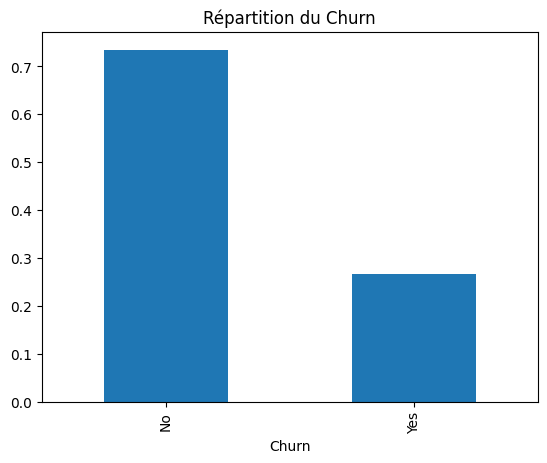

In [36]:
# Répartition de la variable cible
df['Churn'].value_counts(normalize=True).plot(kind='bar', title='Répartition du Churn');

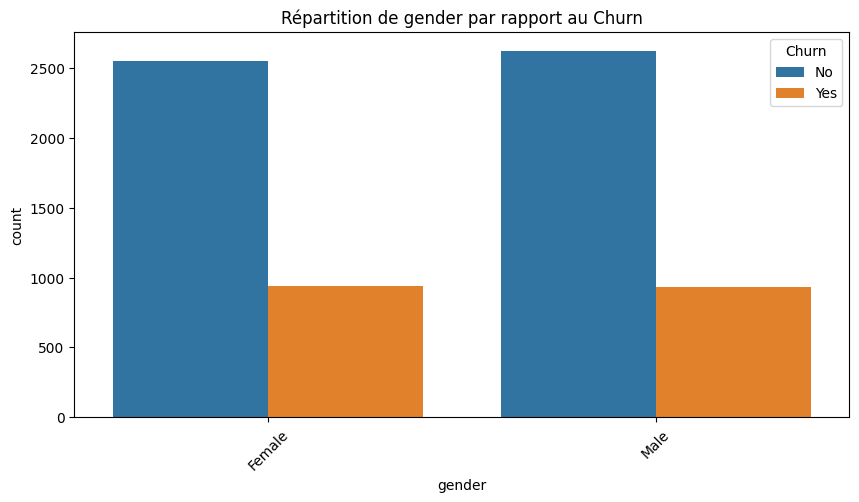

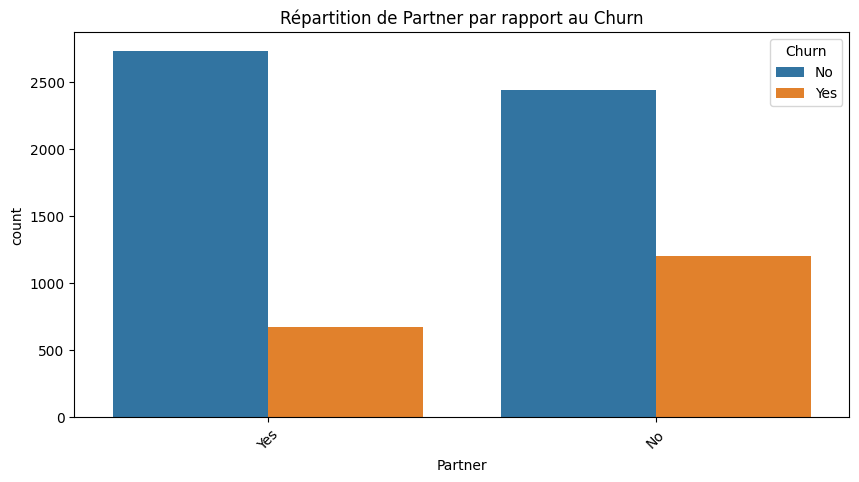

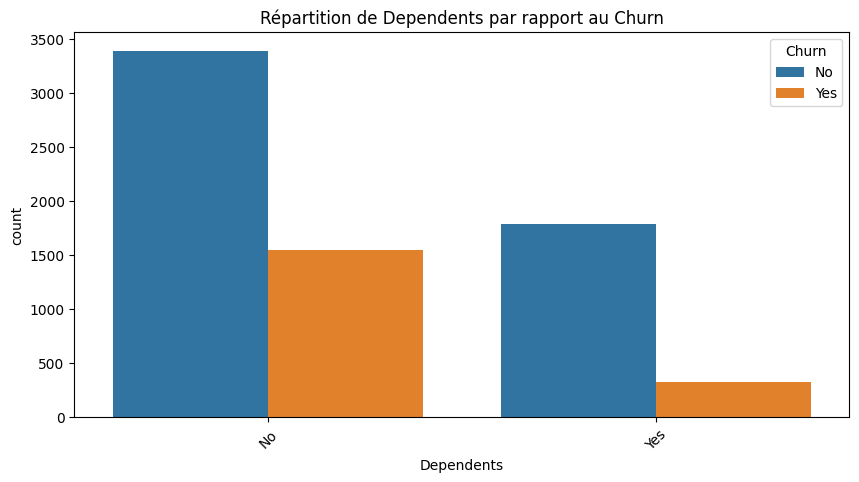

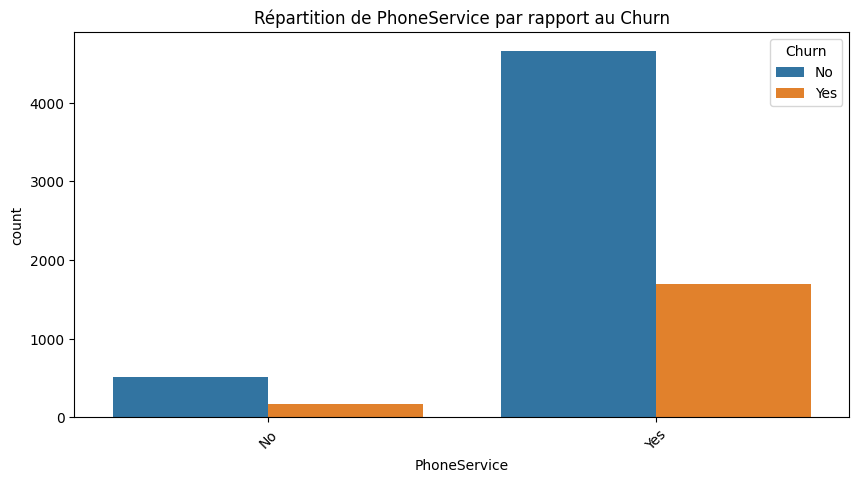

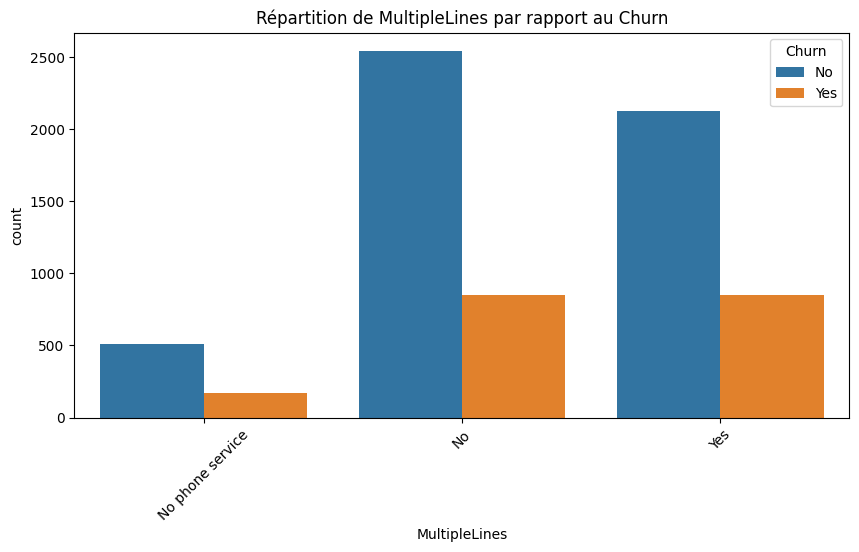

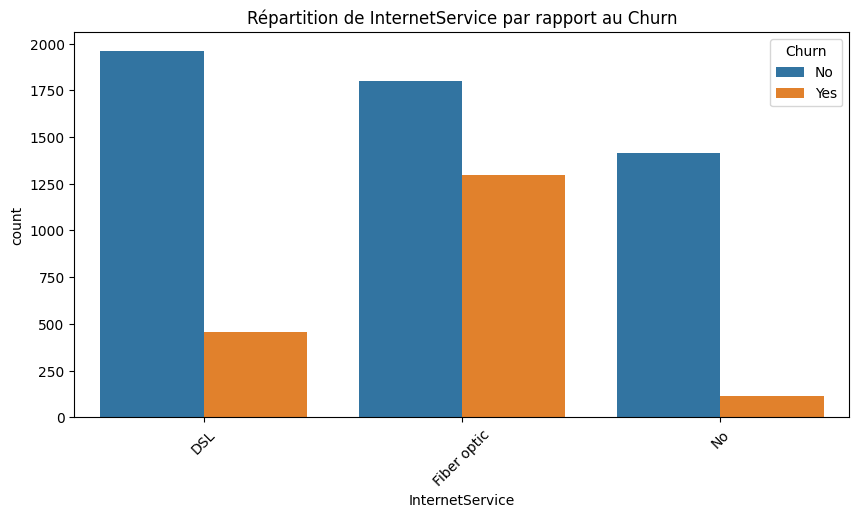

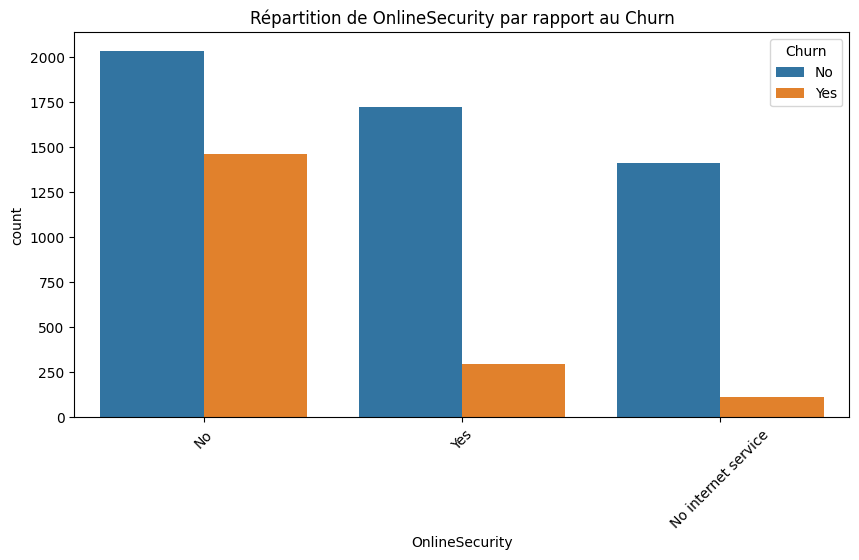

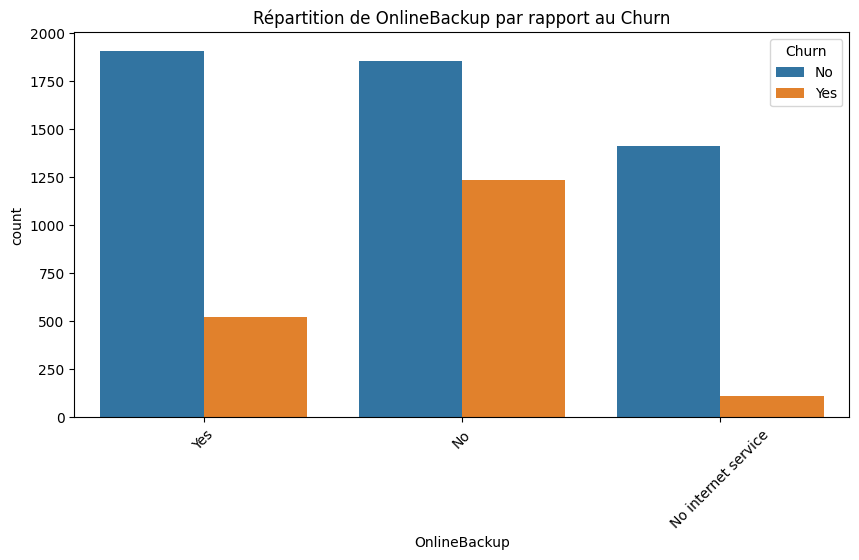

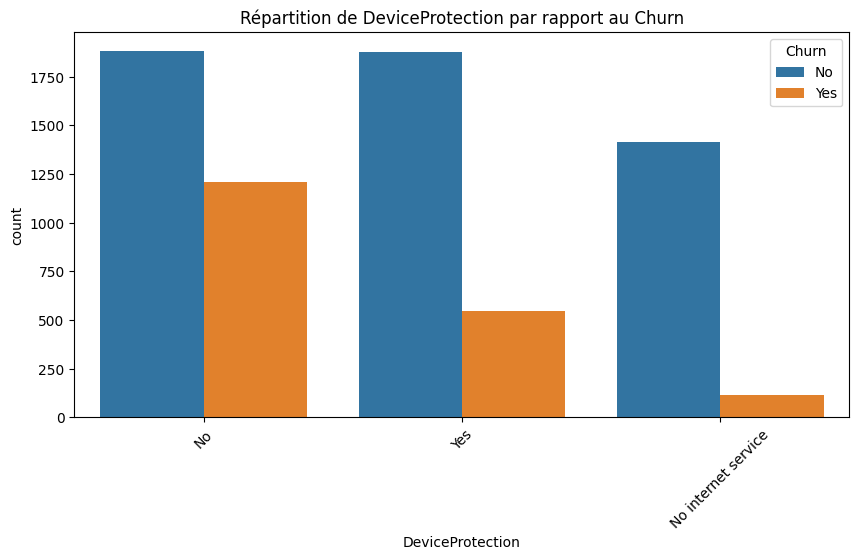

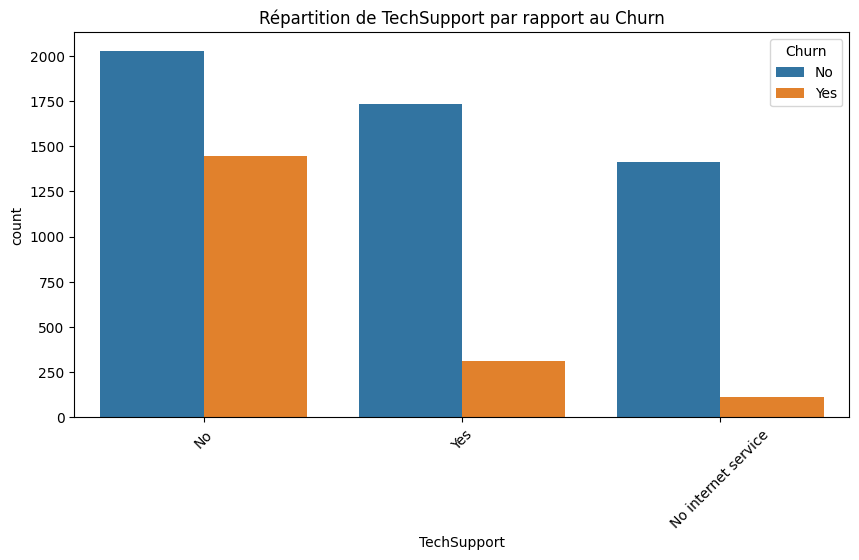

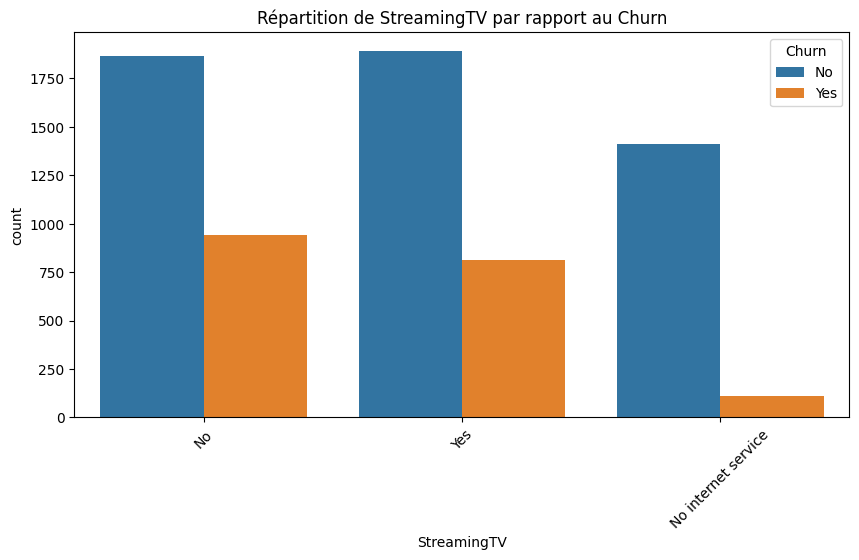

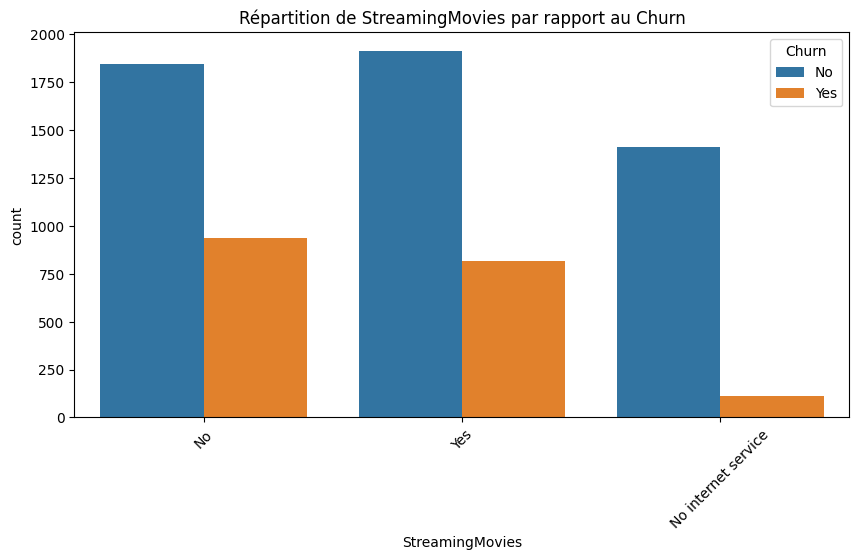

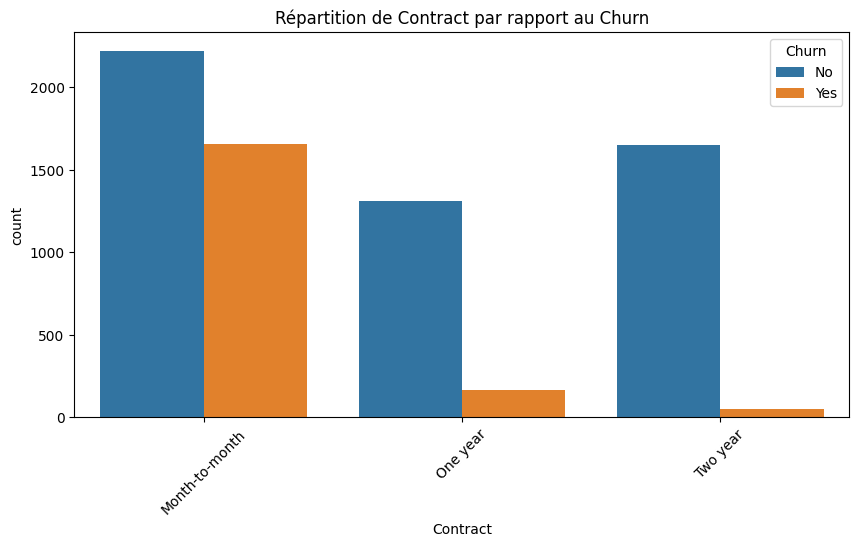

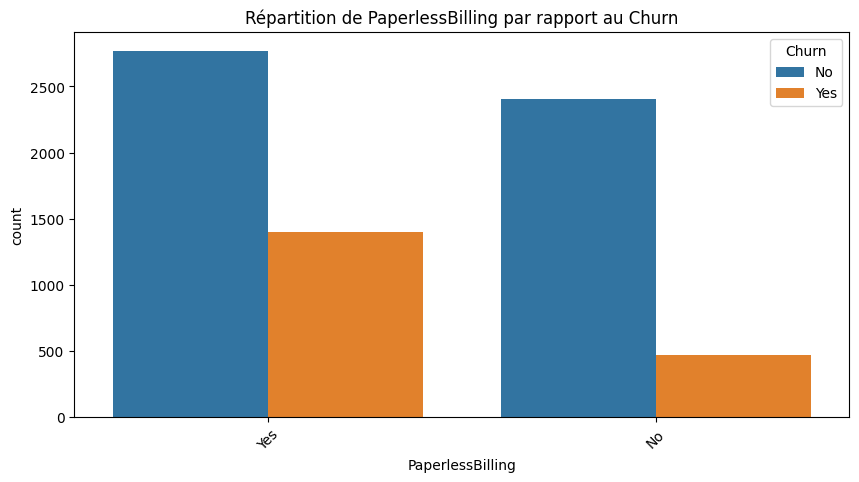

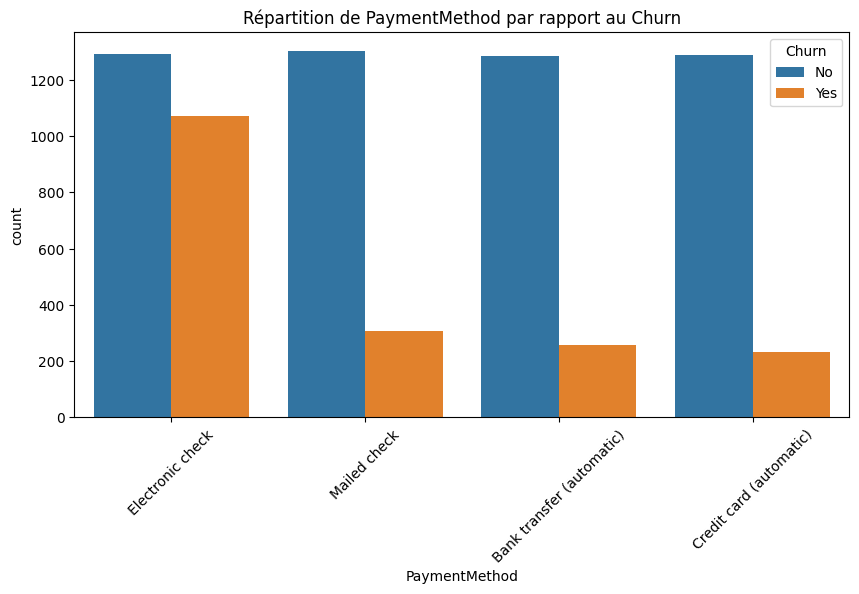

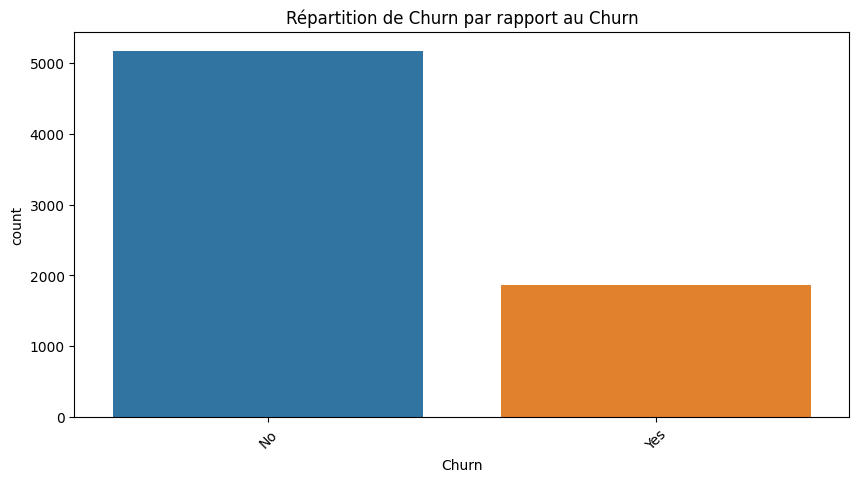

In [37]:
# Visualisation de la répartition des variables catégorielles
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=col, hue='Churn')
    plt.title(f"Répartition de {col} par rapport au Churn")
    plt.xticks(rotation=45)
    plt.show()


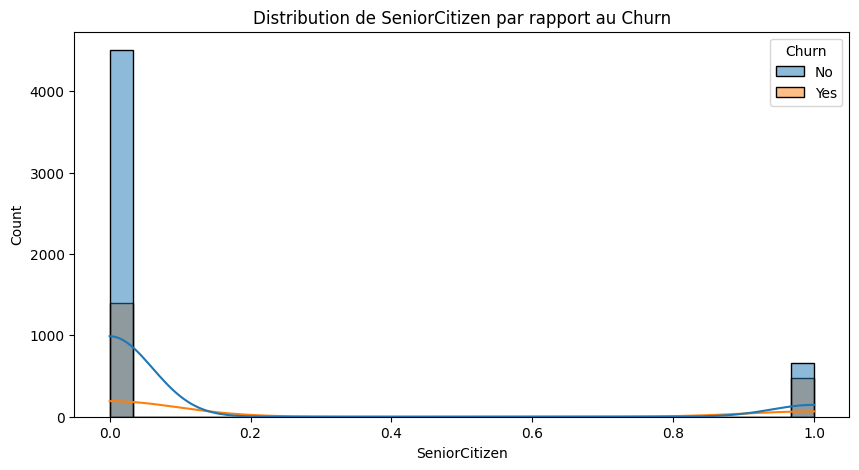

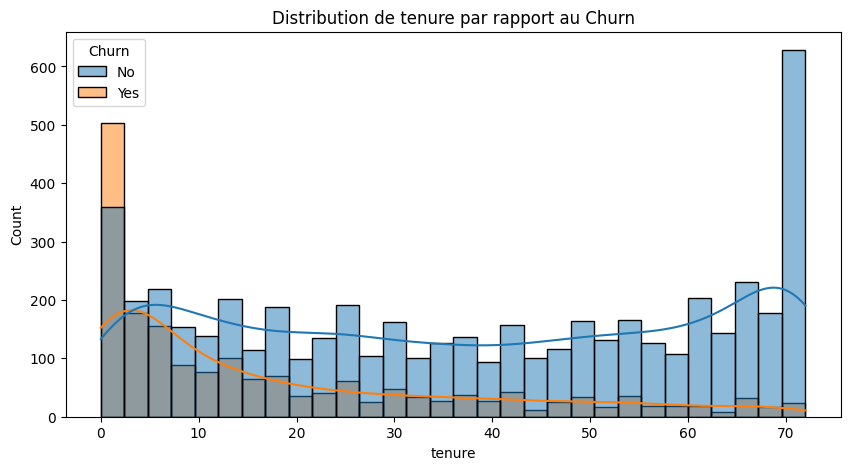

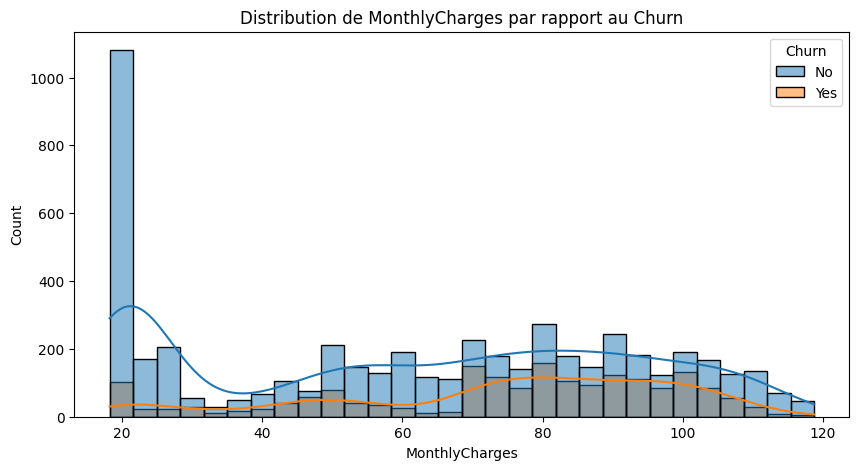

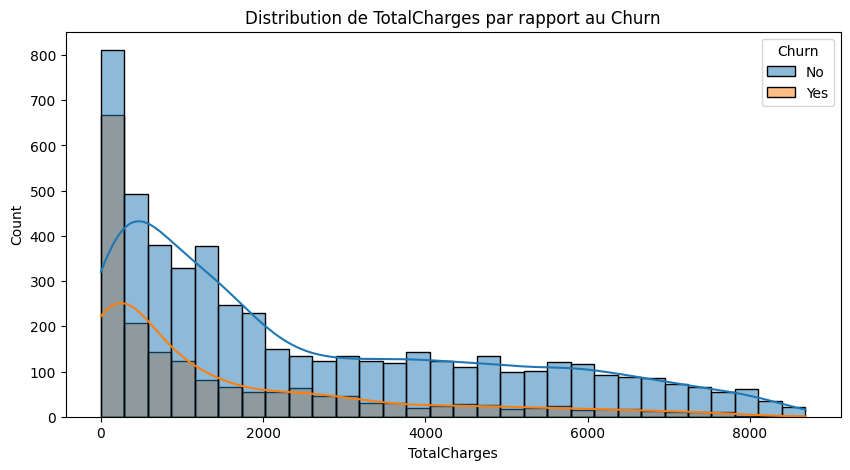

In [39]:
# Sélection des colonnes numériques sans 'Churn'
numerical_cols = df.select_dtypes(include=[np.number]).columns

# Visualisation de la répartition des variables numériques
for col in numerical_cols:
    plt.figure(figsize=(10, 5))
    sns.histplot(data=df, x=col, hue='Churn', kde=True, bins=30)
    plt.title(f"Distribution de {col} par rapport au Churn")
    plt.show()


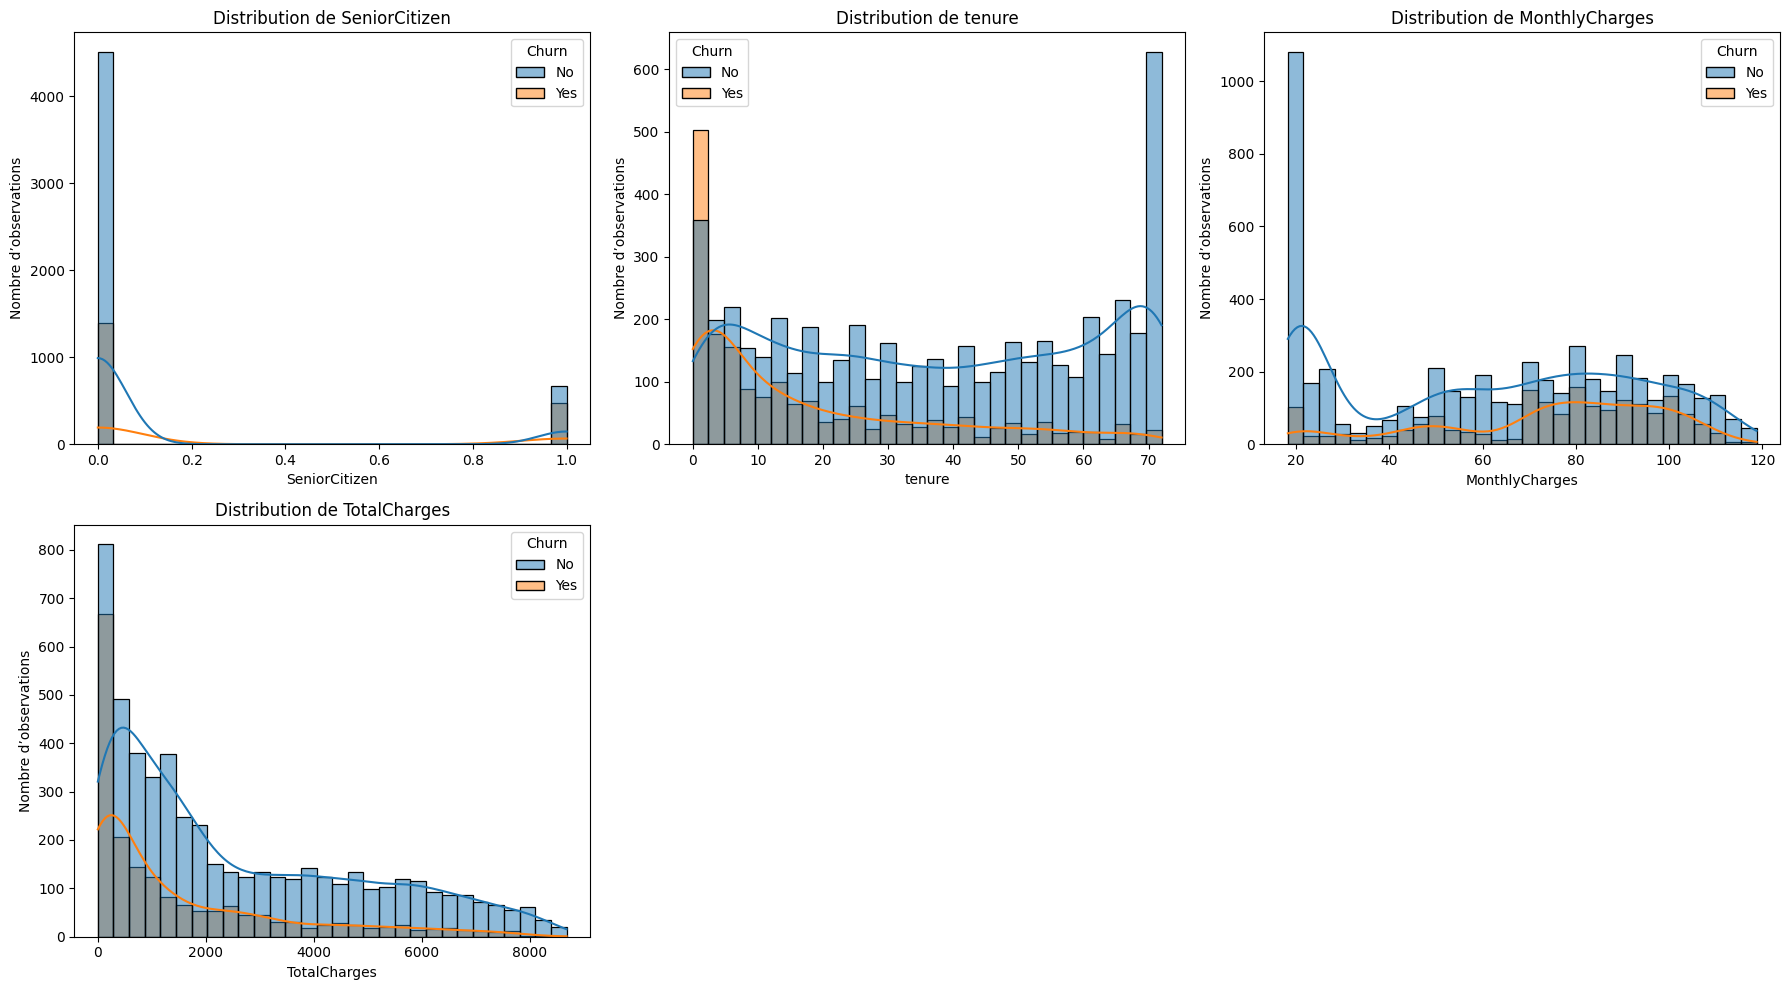

In [41]:


# Sélection des colonnes numériques
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Configuration de la grille : 3 graphiques par ligne
num_cols = len(numeric_cols)
num_rows = (num_cols // 3) + (1 if num_cols % 3 != 0 else 0)  # ajouter une ligne si reste

# Taille de la figure globale
plt.figure(figsize=(18, num_rows * 5))

# Boucle pour tracer chaque variable
for idx, col in enumerate(numeric_cols, 1):
    plt.subplot(num_rows, 3, idx)
    sns.histplot(data=df, x=col, hue='Churn', kde=True, bins=30)
    plt.title(f"Distribution de {col}")
    plt.xlabel(col)
    plt.ylabel('Nombre d’observations')

# Ajuster les espacements
plt.tight_layout()
plt.show()


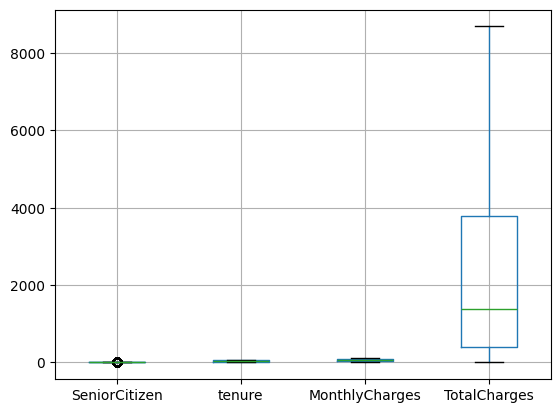

In [42]:
df.boxplot()
plt.show()

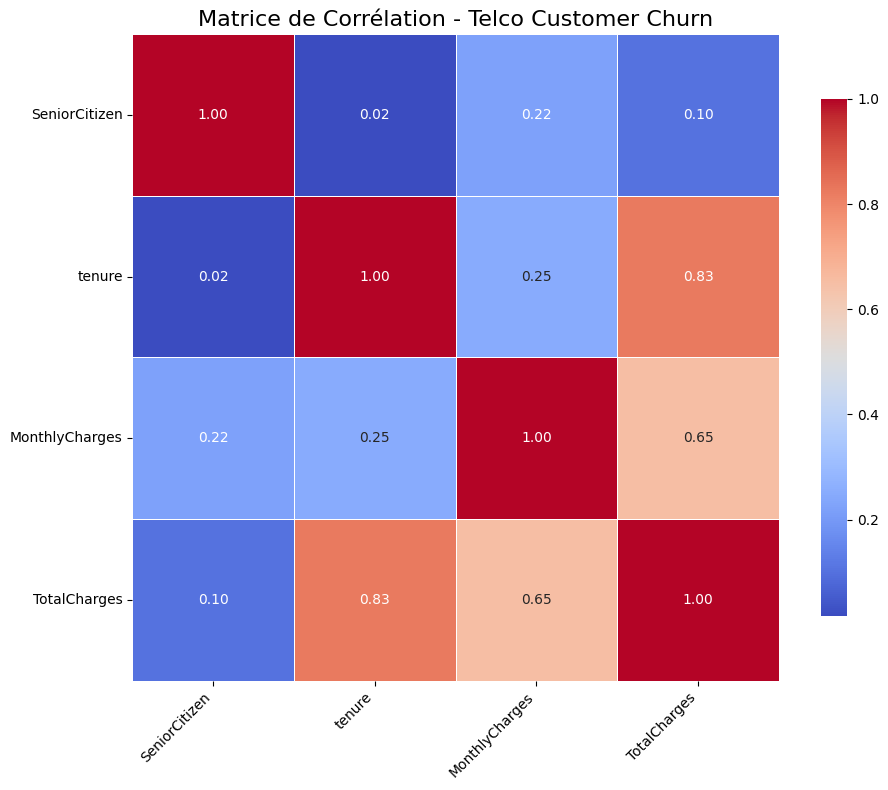

In [43]:

# Matrice de corrélation sur les variables numériques
plt.figure(figsize=(10, 8))  # Taille un peu plus grande pour plus de lisibilité
corr_matrix = df.select_dtypes(include=['number']).corr()

sns.heatmap(
    corr_matrix,
    annot=True,           # Afficher les coefficients
    fmt=".2f",             # Format des nombres
    cmap="coolwarm",       # Couleurs
    linewidths=0.5,        # Espacement entre les cases
    square=True,           # Carrés parfaits pour les cases
    cbar_kws={"shrink": .8} # Réduire la taille de la barre de couleur
)

plt.title("Matrice de Corrélation - Telco Customer Churn", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# Prétraitement des données

In [49]:
# Encoder la variable cible 'Churn'
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

df_encoded = pd.get_dummies(df, drop_first=True)  # drop_first=True pour éviter la multicolinéarité


In [50]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']


In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [53]:
# Appliquer StandardScaler sur toutes les colonnes (car toutes sont numériques maintenant)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Modélisation

* ### Régression logistique

In [54]:
# Modèle
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_scaled, y_train)

# Prédictions
y_pred = logreg.predict(X_test_scaled)
y_pred_proba = logreg.predict_proba(X_test_scaled)[:, 1]  # Probabilité pour ROC


In [55]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")


Accuracy: 0.8070
Precision: 0.6584
Recall: 0.5668
F1 Score: 0.6092
ROC AUC: 0.8418


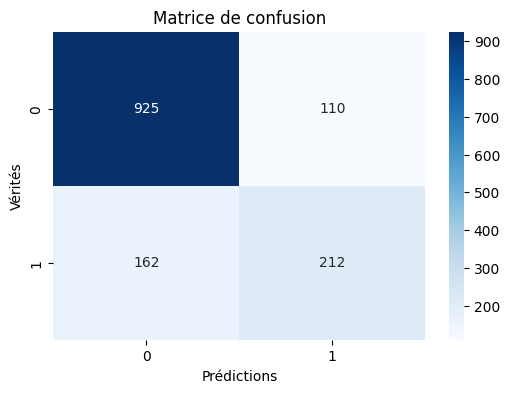

In [56]:
conf_mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de confusion')
plt.xlabel('Prédictions')
plt.ylabel('Vérités')
plt.show()


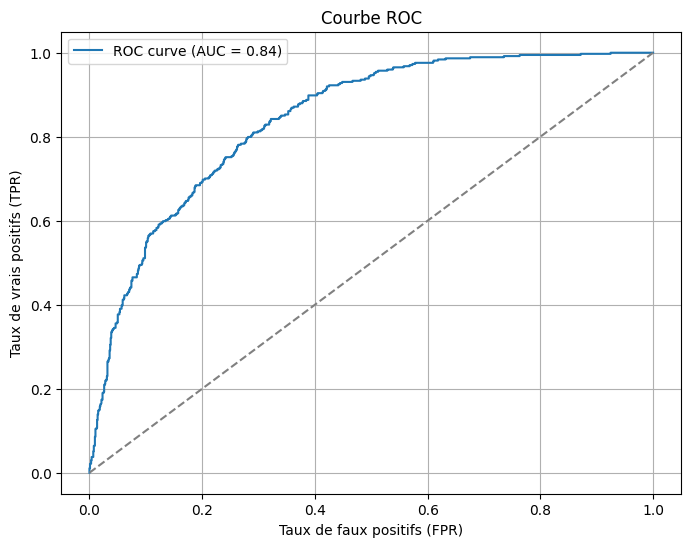

In [57]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc_score(y_test, y_pred_proba):.2f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('Courbe ROC')
plt.legend()
plt.grid()
plt.show()


* ### XGBoost

In [61]:
#%pip install xgboost

import xgboost as xgb
from xgboost import XGBClassifier

In [62]:
# Définir le modèle XGBoost
xgb_model = XGBClassifier(
    use_label_encoder=False,  # Pour éviter warning
    eval_metric='logloss',    # Métrique classique pour classification
    random_state=42
)

# Entraînement
xgb_model.fit(X_train_scaled, y_train)


C:\Users\mdied\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [18:21:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [63]:
# Prédictions
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]


In [64]:
print("Évaluation du modèle XGBoost :")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_xgb):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")


Évaluation du modèle XGBoost :
Accuracy: 0.7722
Precision: 0.5831
Recall: 0.4973
F1 Score: 0.5368
ROC AUC: 0.8224


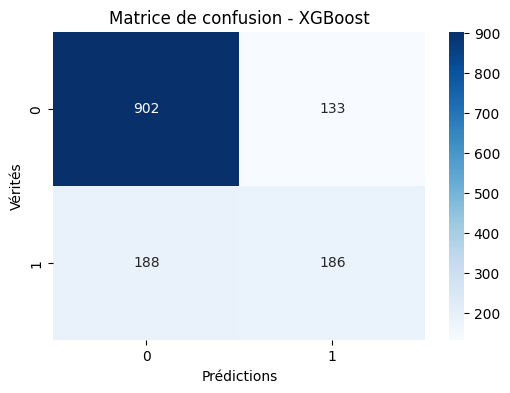

In [65]:
conf_mat_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_mat_xgb, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de confusion - XGBoost')
plt.xlabel('Prédictions')
plt.ylabel('Vérités')
plt.show()


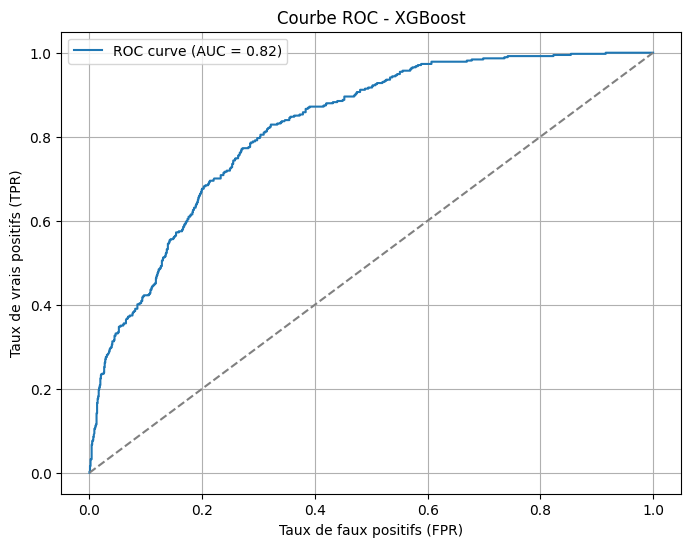

In [66]:
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_pred_proba_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, label=f"ROC curve (AUC = {roc_auc_score(y_test, y_pred_proba_xgb):.2f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('Courbe ROC - XGBoost')
plt.legend()
plt.grid()
plt.show()


Le modèle XGBoost est légèrement moins performant que la régression logistique de base ❌.

Surtout sur le Recall (49.7% vs 56.7%) ➔ donc il détecte moins bien les churners.

Le ROC AUC reste bon (0.82), mais il est inférieur à celui de ta logistique (0.84).

# Rééquilibrage les classes

* ### Régression Logistique (avec class_weight='balanced')

In [67]:
#from sklearn.linear_model import LogisticRegression

# Modèle avec rééquilibrage automatique
logreg_balanced = LogisticRegression(class_weight='balanced', max_iter=1000)
logreg_balanced.fit(X_train_scaled, y_train)

# Prédictions
y_pred_balanced = logreg_balanced.predict(X_test_scaled)
y_pred_proba_balanced = logreg_balanced.predict_proba(X_test_scaled)[:, 1]


In [77]:
print("Évaluation du modèle de rég log avec class_weight='balanced' :")
print(f"Accuracy: {accuracy_score(y_test, y_pred_balanced):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_balanced):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_balanced):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_balanced):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_proba_balanced):.4f}")

Évaluation du modèle de rég log avec class_weight='balanced' :
Accuracy: 0.7402
Precision: 0.5069
Recall: 0.7861
F1 Score: 0.6164
ROC AUC: 0.8414


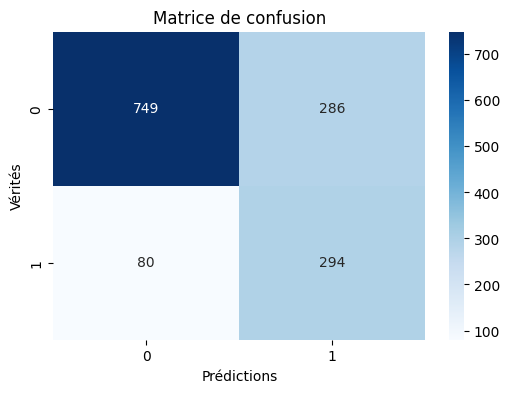

In [70]:
conf_mat = confusion_matrix(y_test, y_pred_balanced)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de confusion')
plt.xlabel('Prédictions')
plt.ylabel('Vérités')
plt.show()

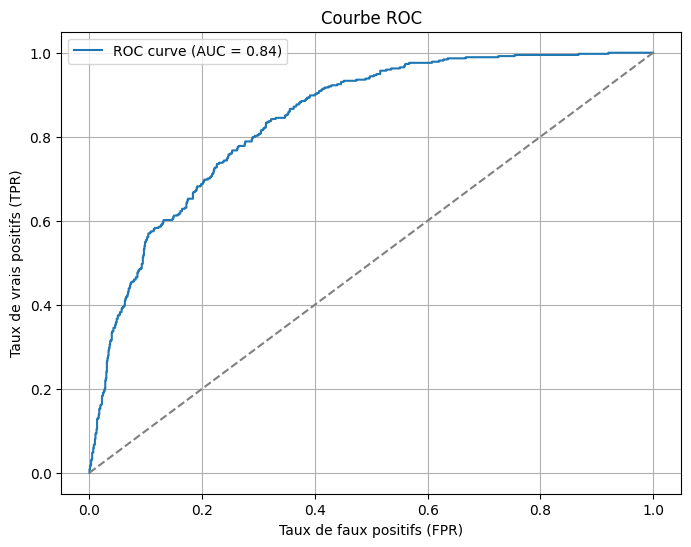

In [71]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_balanced)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc_score(y_test, y_pred_proba_balanced):.2f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('Courbe ROC')
plt.legend()
plt.grid()
plt.show()


* ### XGBoost (avec scale_pos_weight)

In [72]:
# Calcul du poids à appliquer
n_negative = (y_train == 0).sum()
n_positive = (y_train == 1).sum()
scale_pos_weight = n_negative / n_positive

print(f"Scale_pos_weight = {scale_pos_weight:.2f}")


Scale_pos_weight = 2.77


In [73]:
#from xgboost import XGBClassifier

# Modèle XGBoost équilibré
xgb_balanced = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

# Entraînement
xgb_balanced.fit(X_train_scaled, y_train)

# Prédictions
y_pred_xgb_balanced = xgb_balanced.predict(X_test_scaled)
y_pred_proba_xgb_balanced = xgb_balanced.predict_proba(X_test_scaled)[:, 1]


C:\Users\mdied\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [18:36:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [78]:
print("Évaluation du modèle XGBoost avec scale_pos_weight:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb_balanced):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb_balanced):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb_balanced):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_xgb_balanced):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_proba_xgb_balanced):.4f}")

Évaluation du modèle XGBoost avec scale_pos_weight:
Accuracy: 0.7573
Precision: 0.5328
Recall: 0.6952
F1 Score: 0.6032
ROC AUC: 0.8194


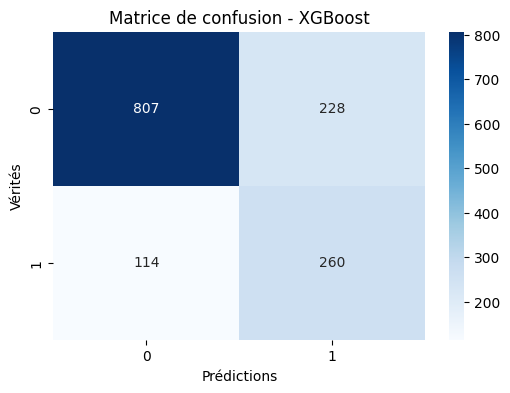

In [75]:
conf_mat_xgb = confusion_matrix(y_test, y_pred_xgb_balanced)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_mat_xgb, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de confusion - XGBoost')
plt.xlabel('Prédictions')
plt.ylabel('Vérités')
plt.show()

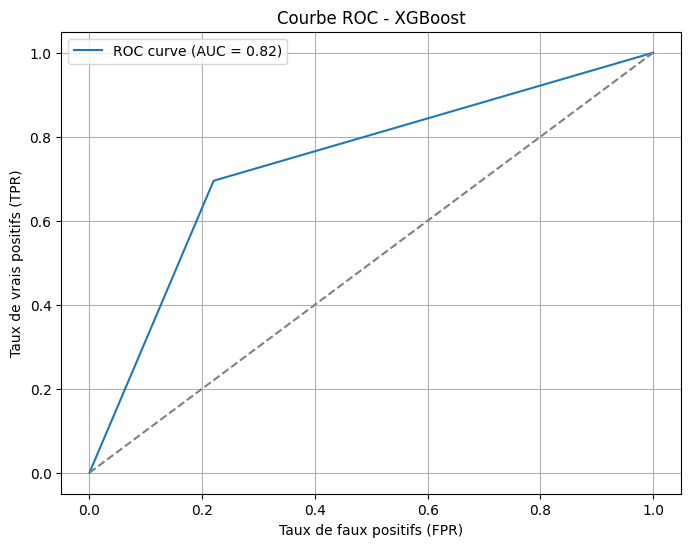

In [76]:
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_pred_xgb_balanced)

plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, label=f"ROC curve (AUC = {roc_auc_score(y_test, y_pred_proba_xgb_balanced):.2f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('Courbe ROC - XGBoost')
plt.legend()
plt.grid()
plt.show()

Pour Recall : 🔥 Régression logistique équilibrée est la meilleure pour détecter un maximum de churners.

Pour F1 Score : les deux modèles équilibrés sont meilleurs que les modèles bruts.

Pour ROC AUC : légère supériorité pour la régression logistique équilibrée.

Donc actuellement :

✅ La Régression Logistique équilibrée est ton meilleur modèle de base pour détecter le churn sur ce dataset

# Testons d'autres modèles 

In [81]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from lightgbm import LGBMClassifier


* ### GradientBoostingClassifier

In [82]:
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_scaled, y_train)

y_pred_gb = gb_model.predict(X_test_scaled)
y_pred_proba_gb = gb_model.predict_proba(X_test_scaled)[:, 1]


* ### SVC (avec probability=True pour ROC)

In [83]:
svc_model = SVC(probability=True, random_state=42)
svc_model.fit(X_train_scaled, y_train)

y_pred_svc = svc_model.predict(X_test_scaled)
y_pred_proba_svc = svc_model.predict_proba(X_test_scaled)[:, 1]


* ### LightGBM (LGBMClassifier)

In [86]:
lgbm_model = LGBMClassifier(random_state=42)
lgbm_model.fit(X_train_scaled, y_train)

y_pred_lgbm = lgbm_model.predict(X_test_scaled)
y_pred_proba_lgbm = lgbm_model.predict_proba(X_test_scaled)[:, 1]


[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002212 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 665
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328


C:\Users\mdied\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\mdied\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


* ### Évaluer les modèles

In [87]:
def evaluate_model(y_true, y_pred, y_pred_proba, model_name):
    print(f"=== {model_name} ===")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall: {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_true, y_pred):.4f}")
    print(f"ROC AUC: {roc_auc_score(y_true, y_pred_proba):.4f}")
    print()

# Appeler pour chaque modèle :
evaluate_model(y_test, y_pred_gb, y_pred_proba_gb, "Gradient Boosting")
evaluate_model(y_test, y_pred_svc, y_pred_proba_svc, "SVC")
evaluate_model(y_test, y_pred_lgbm, y_pred_proba_lgbm, "LightGBM")

=== Gradient Boosting ===
Accuracy: 0.7977
Precision: 0.6540
Recall: 0.5053
F1 Score: 0.5701
ROC AUC: 0.8415

=== SVC ===
Accuracy: 0.7928
Precision: 0.6444
Recall: 0.4893
F1 Score: 0.5562
ROC AUC: 0.7961

=== LightGBM ===
Accuracy: 0.7906
Precision: 0.6270
Recall: 0.5214
F1 Score: 0.5693
ROC AUC: 0.8358



* ### Comparaison

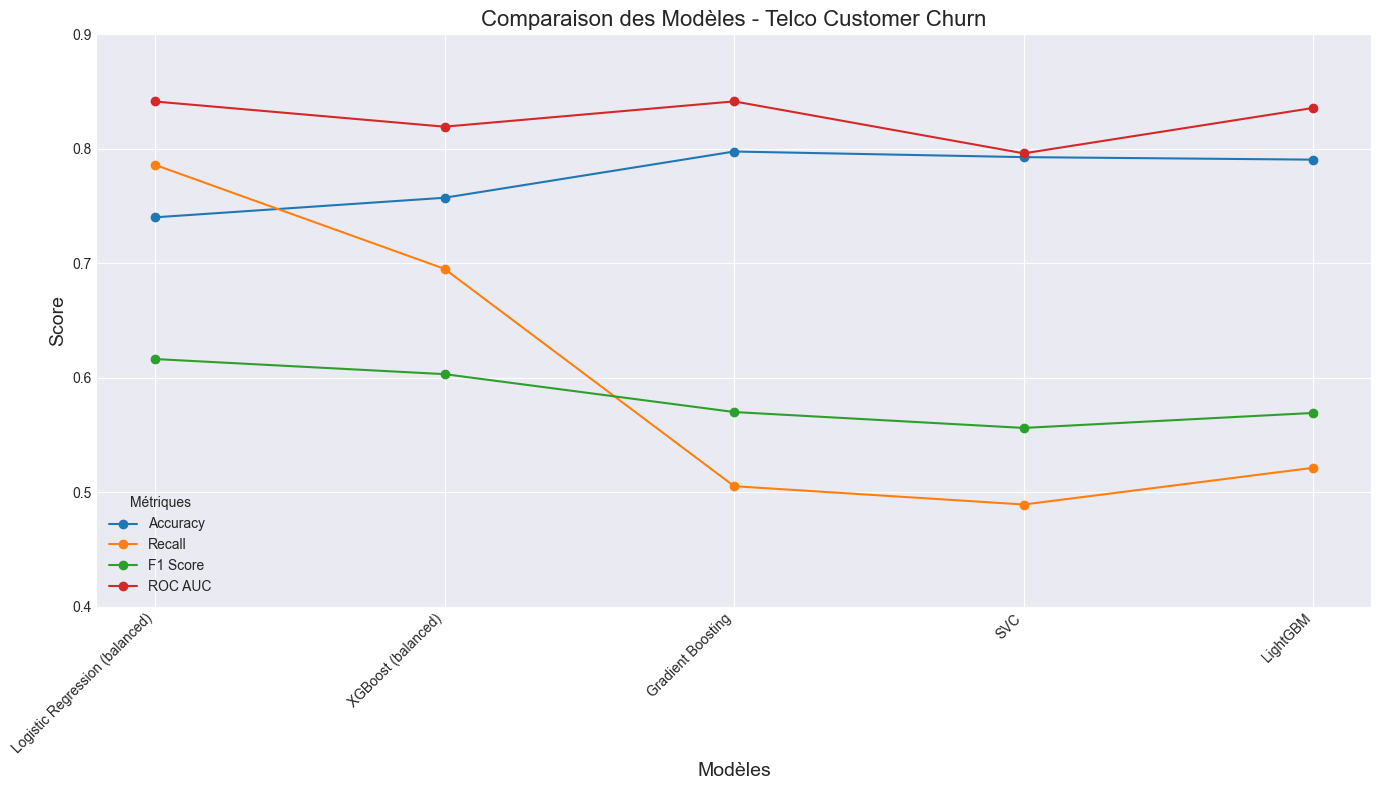

In [88]:
# Résultats manuels des modèles (ceux que tu as obtenus)
results = {
    'Model': [
        'Logistic Regression (balanced)', 
        'XGBoost (balanced)', 
        'Gradient Boosting', 
        'SVC', 
        'LightGBM'
    ],
    'Accuracy': [0.7402, 0.7573, 0.7977, 0.7928, 0.7906],
    'Recall': [0.7861, 0.6952, 0.5053, 0.4893, 0.5214],
    'F1 Score': [0.6164, 0.6032, 0.5701, 0.5562, 0.5693],
    'ROC AUC': [0.8414, 0.8194, 0.8415, 0.7961, 0.8358]
}

# Conversion en DataFrame
df_results = pd.DataFrame(results)

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')

# Taille de la figure
plt.figure(figsize=(14, 8))

# Plot
metrics = ['Accuracy', 'Recall', 'F1 Score', 'ROC AUC']
for metric in metrics:
    plt.plot(df_results['Model'], df_results[metric], marker='o', label=metric)

# Décorations
plt.title('Comparaison des Modèles - Telco Customer Churn', fontsize=16)
plt.xlabel('Modèles', fontsize=14)
plt.ylabel('Score', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylim(0.4, 0.9)
plt.legend(title="Métriques")
plt.grid(True)
plt.tight_layout()

# Affichage
plt.show()

Si l'objectif est de maximiser le Recall (détecter un maximum de churners),
➔ Régression Logistique équilibrée reste la meilleure ✅

# L'importance des variables caractéristiques

C:\Users\mdied\AppData\Local\Temp\ipykernel_139344\1231819233.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


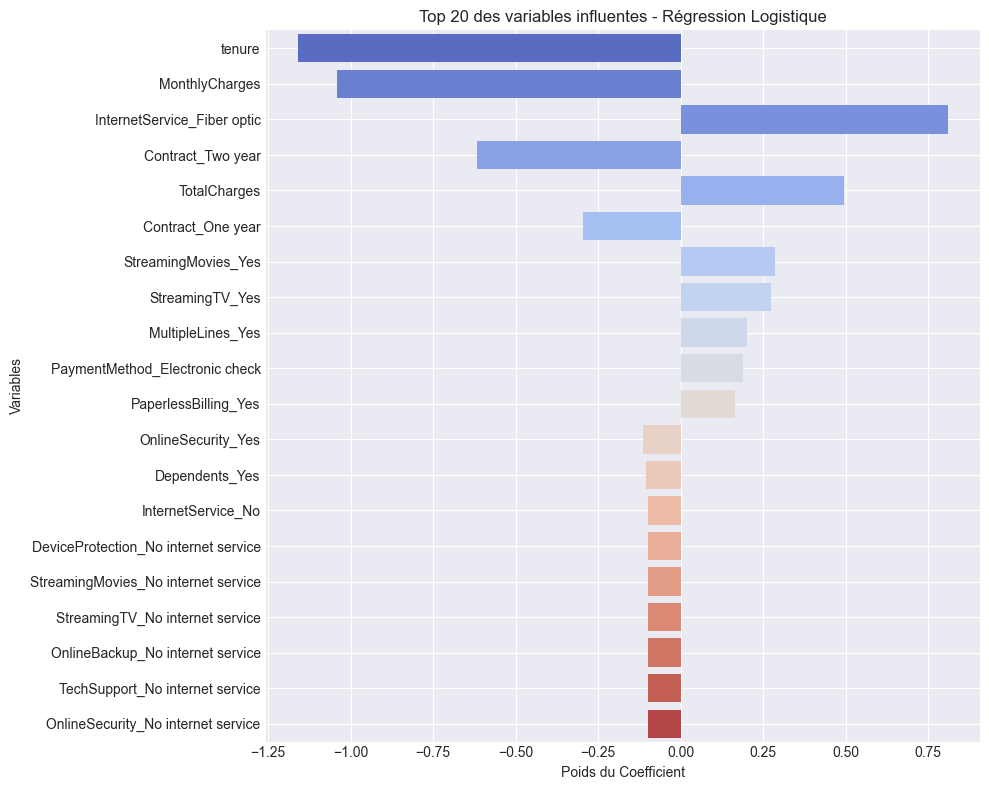

,Feature,Coefficient
1,tenure,-1.159048
2,MonthlyCharges,-1.039440
10,InternetService_Fiber optic,0.808897
25,Contract_Two year,-0.617746
3,TotalCharges,0.494748
24,Contract_One year,-0.296706
23,StreamingMovies_Yes,0.285948
21,StreamingTV_Yes,0.273209
9,MultipleLines_Yes,0.201165
28,PaymentMethod_Electronic check,0.188783


In [89]:
# Récupérer les coefficients
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': logreg_balanced.coef_[0]
})

# Trier par importance absolue
coefficients['abs_coef'] = coefficients['Coefficient'].abs()
coefficients = coefficients.sort_values(by='abs_coef', ascending=False)

# Affichage
plt.figure(figsize=(10, 8))
sns.barplot(
    data=coefficients.head(20), 
    y='Feature', 
    x='Coefficient', 
    palette='coolwarm'
)
plt.title("Top 20 des variables influentes - Régression Logistique")
plt.xlabel("Poids du Coefficient")
plt.ylabel("Variables")
plt.grid(True)
plt.tight_layout()
plt.show()

# Affichage brut si besoin
coefficients[['Feature', 'Coefficient']].head(20)


Clients récents, fibre optique, facturation électronique, paiement électronique, services de streaming ➔ Risque de churn plus élevé.

Clients anciens, contrat de 1 ou 2 ans, sécurité en ligne ➔ Moins de churn.



In [91]:
import joblib

# Sauvegarder
joblib.dump(logreg_balanced, 'C:/Users/mdied/OneDrive/Documents/Projets Personnels/telco_churn_prediction/models/logreg_balanced.pkl')
joblib.dump(scaler, 'C:/Users/mdied/OneDrive/Documents/Projets Personnels/telco_churn_prediction/models/scaler.pkl')


['C:/Users/mdied/OneDrive/Documents/Projets Personnels/telco_churn_prediction/models/scaler.pkl']

# TEST

In [94]:
print(list(X_train.columns))


['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [96]:
import sys
import os

# Ajouter le chemin du projet (le dossier TELCO_CHURN_PREDICTION) dans sys.path
sys.path.append(os.path.abspath(".."))


In [97]:
# Importer la fonction de prédiction
from src.predict import predict_churn

# Exemple d'un client fictif
# Attention : il faut respecter l'ordre des variables du training !
# (Même nombre de variables, même type numérique, etc.)

# Exemple d'un client transformé en liste
example_client = [
    0,   # SeniorCitizen (non)
    5,   # tenure (5 mois)
    75.0,  # MonthlyCharges (75 dollars)
    400.0, # TotalCharges
    1,   # gender_Male
    0,   # Partner_Yes (pas en couple)
    0,   # Dependents_Yes (pas d'enfants)
    1,   # PhoneService_Yes
    0,   # MultipleLines_No phone service
    1,   # MultipleLines_Yes
    1,   # InternetService_Fiber optic
    0,   # InternetService_No
    0,   # OnlineSecurity_No internet service
    0,   # OnlineSecurity_Yes
    0,   # OnlineBackup_No internet service
    0,   # OnlineBackup_Yes
    0,   # DeviceProtection_No internet service
    0,   # DeviceProtection_Yes
    0,   # TechSupport_No internet service
    0,   # TechSupport_Yes
    0,   # StreamingTV_No internet service
    1,   # StreamingTV_Yes
    0,   # StreamingMovies_No internet service
    1,   # StreamingMovies_Yes
    0,   # Contract_One year
    0,   # Contract_Two year
    1,   # PaperlessBilling_Yes
    0,   # PaymentMethod_Credit card (automatic)
    1,   # PaymentMethod_Electronic check
    0    # PaymentMethod_Mailed check
]


# Lancer la prédiction
prediction = predict_churn(example_client)

# Afficher le résultat
print(f"Résultat de la prédiction : {'Churn' if prediction == 1 else 'Pas de churn'}")


Résultat de la prédiction : Churn


C:\Users\mdied\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
